## Review 평점과 Sales 연관성

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Data Load

In [8]:
data = pd.read_csv("review-rv_sales 1_csv.csv")

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   yr_month            390 non-null    int64  
 1   financial_category  390 non-null    object 
 2   written_avg_rating  390 non-null    float64
 3   written_12_cnt      390 non-null    int64  
 4   written_all_cnt     390 non-null    int64  
 5   written_12_ratio    390 non-null    float64
 6   all_avg_rating      350 non-null    float64
 7   all_12_cnt          350 non-null    float64
 8   all_all_cnt         350 non-null    float64
 9   all_12_ratio        350 non-null    float64
 10  sales_amount        390 non-null    float64
 11  sales_qty           390 non-null    int64  
dtypes: float64(7), int64(4), object(1)
memory usage: 36.7+ KB


In [12]:
data['yr_month'] = pd.to_datetime(data['yr_month'], format='%Y%m')

In [14]:
mattress_categories = ["Foam Mattresses","Spring Mattresses"]
data["category_type"] = data["financial_category"].apply(lambda x: "Mattress" if x in mattress_categories else "Non-Mattress")

In [16]:
data

,yr_month,financial_category,written_avg_rating,written_12_cnt,written_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,category_type
0,2022-12-01,SmartBases,4.038674,37,181,0.204420,4.512716,73.0,983.0,0.074262,1729285.82,17377,Non-Mattress
1,2024-12-01,Platform Beds,3.854545,103,440,0.234091,3.854545,103.0,440.0,0.234091,4021850.94,40099,Non-Mattress
2,2023-09-01,Toppers,3.106061,31,66,0.469697,4.163462,61.0,416.0,0.146635,240646.93,4615,Non-Mattress
3,2022-01-01,Non Bedroom Furniture,3.853333,19,75,0.253333,NaN,NaN,NaN,NaN,518281.03,4766,Non-Mattress
4,2024-11-01,Others,5.000000,0,2,0.000000,4.833333,0.0,6.0,0.000000,41752.46,1279,Non-Mattress
...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,2023-03-01,Toppers,2.700637,89,157,0.566879,3.853425,166.0,730.0,0.227397,1018152.28,20058,Non-Mattress
386,2023-11-01,Box Springs,3.840206,49,194,0.252577,4.371156,100.0,943.0,0.106045,4148741.49,31839,Non-Mattress
387,2022-02-01,Box Springs,4.133739,56,329,0.170213,NaN,NaN,NaN,NaN,6632445.72,48676,Non-Mattress
388,2024-01-01,Toppers,3.041667,21,48,0.437500,4.150602,48.0,332.0,0.144578,185152.78,3537,Non-Mattress


## 상관계수 히트맵

In [32]:
# 수치형 컬럼만 선택
#numeric_cols = ['all_avg_rating', 'all_all_cnt', 'written_12_ratio', 'sales_amount']
#numeric_cols = ['written_avg_rating', 'written_12_cnt', 'written_all_cnt', 'written_12_ratio', 'sales_amount']
numeric_cols = ['written_avg_rating', 'written_all_cnt', 'sales_amount']
corr = data[numeric_cols].corr()


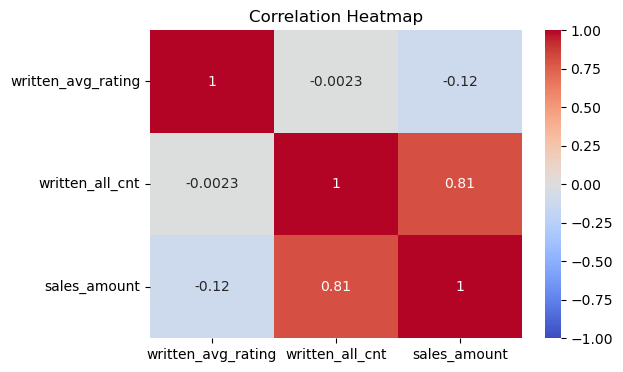

In [34]:

# 히트맵 생성
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

## 회귀 분석 

In [30]:
selected_columns = ["sales_amount","written_avg_rating","written_all_cnt","written_12_cnt","written_12_ratio"]
data1 = data[selected_columns].dropna()

In [32]:
Y = data1['sales_amount']
X = data1.drop(columns=["sales_amount"])

In [34]:
X

,written_avg_rating,written_all_cnt,written_12_cnt,written_12_ratio
0,4.038674,181,37,0.204420
1,3.854545,440,103,0.234091
2,3.106061,66,31,0.469697
3,3.853333,75,19,0.253333
4,5.000000,2,0,0.000000
...,...,...,...,...
385,2.700637,157,89,0.566879
386,3.840206,194,49,0.252577
387,4.133739,329,56,0.170213
388,3.041667,48,21,0.437500


In [36]:
X = sm.add_constant(X)

In [38]:
model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           sales_amount   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     366.3
Date:                Thu, 20 Mar 2025   Prob (F-statistic):          8.95e-130
Time:                        08:38:49   Log-Likelihood:                -6349.2
No. Observations:                 390   AIC:                         1.271e+04
Df Residuals:                     385   BIC:                         1.273e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               2.766e+06   7.33

In [40]:
# 다중 공선성
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

             Variable          VIF
0               const  2554.702242
1  written_avg_rating    26.072131
2     written_all_cnt     8.510576
3      written_12_cnt     9.100500
4    written_12_ratio    25.388813


## 평점과 판매액 간의 시계열 

In [43]:
monthly_sales_by_category = data.groupby(['yr_month', 'category_type']).agg({'sales_amount': 'sum', 'written_avg_rating':'mean'}).reset_index()

In [45]:
mattress_data = monthly_sales_by_category[monthly_sales_by_category["category_type"] == "Mattress"]
non_mattress_data = monthly_sales_by_category[monthly_sales_by_category["category_type"] == "Non-Mattress"]

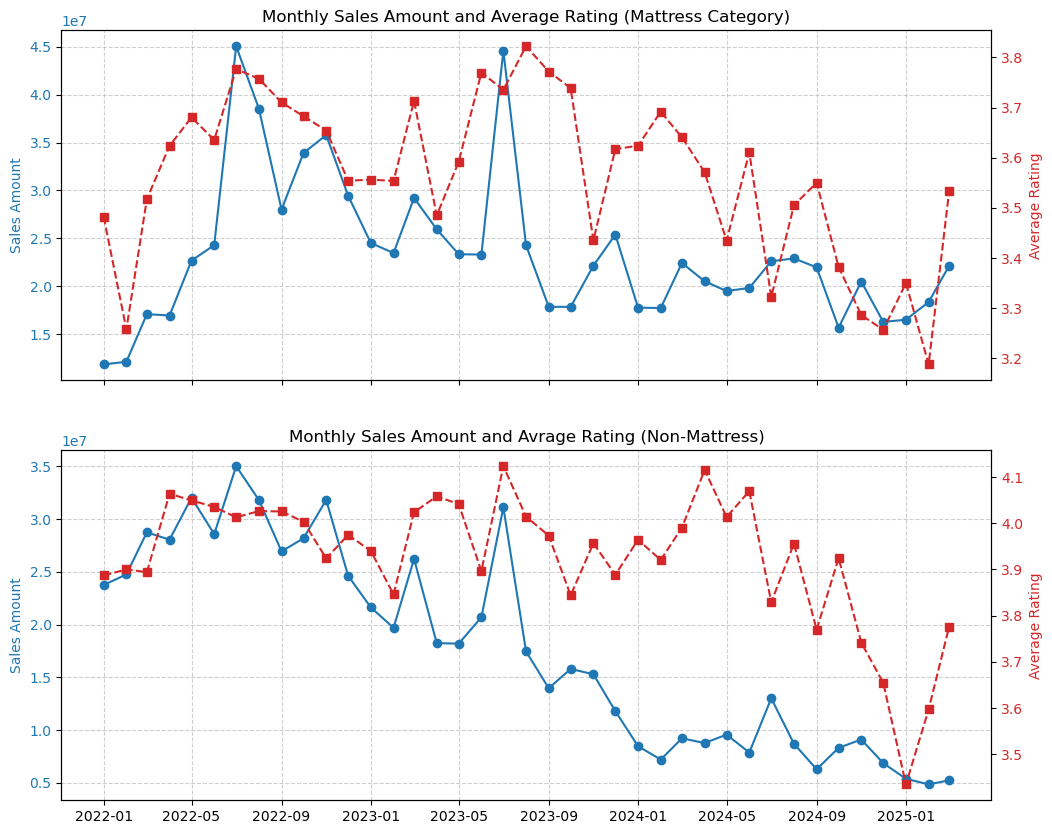

In [47]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,10), sharex=True)

ax1.set_title("Monthly Sales Amount and Average Rating (Mattress Category)") 
#ax1.set_xlabel("Month")
ax1.set_ylabel("Sales Amount", color='tab:blue')
ax1.plot(mattress_data['yr_month'], mattress_data['sales_amount'], marker='o', color='tab:blue', label="Sales Amount")
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.6)

ax3 = ax1.twinx()
ax3.set_ylabel("Average Rating", color='tab:red')
ax3.plot(mattress_data['yr_month'], mattress_data['written_avg_rating'], marker='s', color='tab:red', linestyle='dashed', label="Average Rating")
ax3.tick_params(axis='y', labelcolor='tab:red')

ax2.set_title("Monthly Sales Amount and Avrage Rating (Non-Mattress)")
ax2.set_ylabel("Sales Amount", color='tab:blue')
ax2.plot(non_mattress_data['yr_month'], non_mattress_data['sales_amount'], marker='o', color='tab:blue', label="Sales Amount")
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.grid(True, linestyle='--', alpha=0.6)

ax4 = ax2.twinx()
ax4.set_ylabel("Average Rating", color='tab:red')
ax4.plot(non_mattress_data['yr_month'], non_mattress_data['written_avg_rating'], marker='s', color='tab:red', linestyle='dashed', label="Average Rating")
ax4.tick_params(axis='y', labelcolor='tab:red')

plt.show()


In [49]:
#non_mattress_data['written_avg_rating'].max()
non_mattress_data['written_avg_rating'].min()

3.434789467375

## 평점 수준별 매출 히스토그램

In [52]:
bins = [i/10 for i in range(int(data['written_avg_rating'].min()*10), int(data['written_avg_rating'].max() * 10) + 2)]

In [54]:
data['rating_bin'] = pd.cut(data['written_avg_rating'], bins=bins, right=False)

In [56]:
data[data['category_type']=="Mattress"]['sales_amount'].sum()

912267872.8899999

In [90]:
rating_sales = data.groupby(["rating_bin", "category_type"])["sales_amount"].sum().unstack().fillna(0) / 1000000

C:\Users\최태욱\AppData\Local\Temp\ipykernel_14772\1249324559.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales = data.groupby(["rating_bin", "category_type"])["sales_amount"].sum().unstack().fillna(0) / 1000000


In [112]:
rating_sales_by_category = data.groupby(['rating_bin','financial_category'])['sales_amount'].sum().unstack().fillna(0)/1000000

C:\Users\최태욱\AppData\Local\Temp\ipykernel_14772\3906643850.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales_by_category = data.groupby(['rating_bin','financial_category'])['sales_amount'].sum().unstack().fillna(0)/1000000


In [114]:
rating_sales_by_category

financial_category,Box Springs,Foam Mattresses,Non Bedroom Furniture,Other Frames & Beds,Others,Platform Beds,SmartBases,Sofa,Spring Mattresses,Toppers
rating_bin,,,,,,,,,,
"[1.0, 1.1)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.089498,0.000000,0.000000
"[1.1, 1.2)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.2, 1.3)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.3, 1.4)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.4, 1.5)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.5, 1.6)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.6, 1.7)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.7, 1.8)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[1.8, 1.9)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


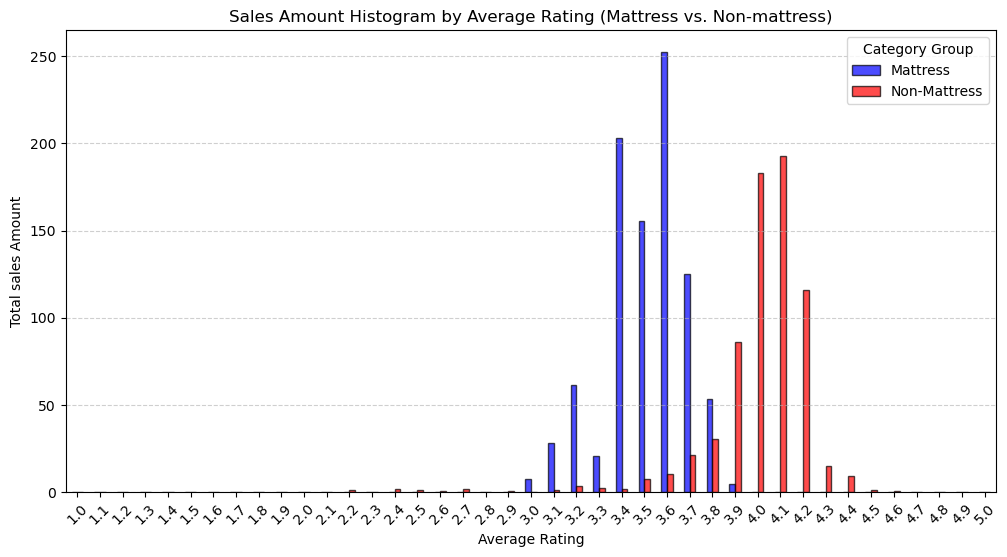

In [92]:
fig, ax = plt.subplots(figsize=(12,6))
rating_sales.plot(kind='bar', stacked=False, color=['blue','red'], edgecolor='black', alpha=0.7, ax=ax)

x_labels = [round(b.left, 1) for b in rating_sales.index]
ax.set_xticklabels(x_labels, rotation=45)

plt.xlabel("Average Rating")
plt.ylabel("Total sales Amount")
plt.title("Sales Amount Histogram by Average Rating (Mattress vs. Non-mattress)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Category Group", labels=["Mattress", "Non-Mattress"])

plt.show()





## Category별 히스토그램 

In [77]:
data

,yr_month,financial_category,written_avg_rating,written_12_cnt,written_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,category_type,rating_bin
0,2022-12-01,SmartBases,4.038674,37,181,0.204420,4.512716,73.0,983.0,0.074262,1729285.82,17377,Non-Mattress,"[4.0, 4.1)"
1,2024-12-01,Platform Beds,3.854545,103,440,0.234091,3.854545,103.0,440.0,0.234091,4021850.94,40099,Non-Mattress,"[3.8, 3.9)"
2,2023-09-01,Toppers,3.106061,31,66,0.469697,4.163462,61.0,416.0,0.146635,240646.93,4615,Non-Mattress,"[3.1, 3.2)"
3,2022-01-01,Non Bedroom Furniture,3.853333,19,75,0.253333,NaN,NaN,NaN,NaN,518281.03,4766,Non-Mattress,"[3.8, 3.9)"
4,2024-11-01,Others,5.000000,0,2,0.000000,4.833333,0.0,6.0,0.000000,41752.46,1279,Non-Mattress,"[5.0, 5.1)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,2023-03-01,Toppers,2.700637,89,157,0.566879,3.853425,166.0,730.0,0.227397,1018152.28,20058,Non-Mattress,"[2.7, 2.8)"
386,2023-11-01,Box Springs,3.840206,49,194,0.252577,4.371156,100.0,943.0,0.106045,4148741.49,31839,Non-Mattress,"[3.8, 3.9)"
387,2022-02-01,Box Springs,4.133739,56,329,0.170213,NaN,NaN,NaN,NaN,6632445.72,48676,Non-Mattress,"[4.1, 4.2)"
388,2024-01-01,Toppers,3.041667,21,48,0.437500,4.150602,48.0,332.0,0.144578,185152.78,3537,Non-Mattress,"[3.0, 3.1)"


In [96]:
categories = data['financial_category'].unique()
num_categories = len(categories)

In [98]:
bins1 = [round(x * 0.1, 1) for x in range(int(data['written_avg_rating'].min()*10)-1, int(data['written_avg_rating'].max()*10)+2)]
#subset['rating_bin']=data.cut(subset['written_avg_rating'], bins=bins1)

C:\Users\최태욱\AppData\Local\Temp\ipykernel_14772\2937017614.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales_sum = subset.groupby('rating_bin1')['sales_amount'].sum().fillna(0) / 1000000
C:\Users\최태욱\AppData\Local\Temp\ipykernel_14772\2937017614.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales_sum = subset.groupby('rating_bin1')['sales_amount'].sum().fillna(0) / 1000000
C:\Users\최태욱\AppData\Local\Temp\ipykernel_14772\2937017614.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain

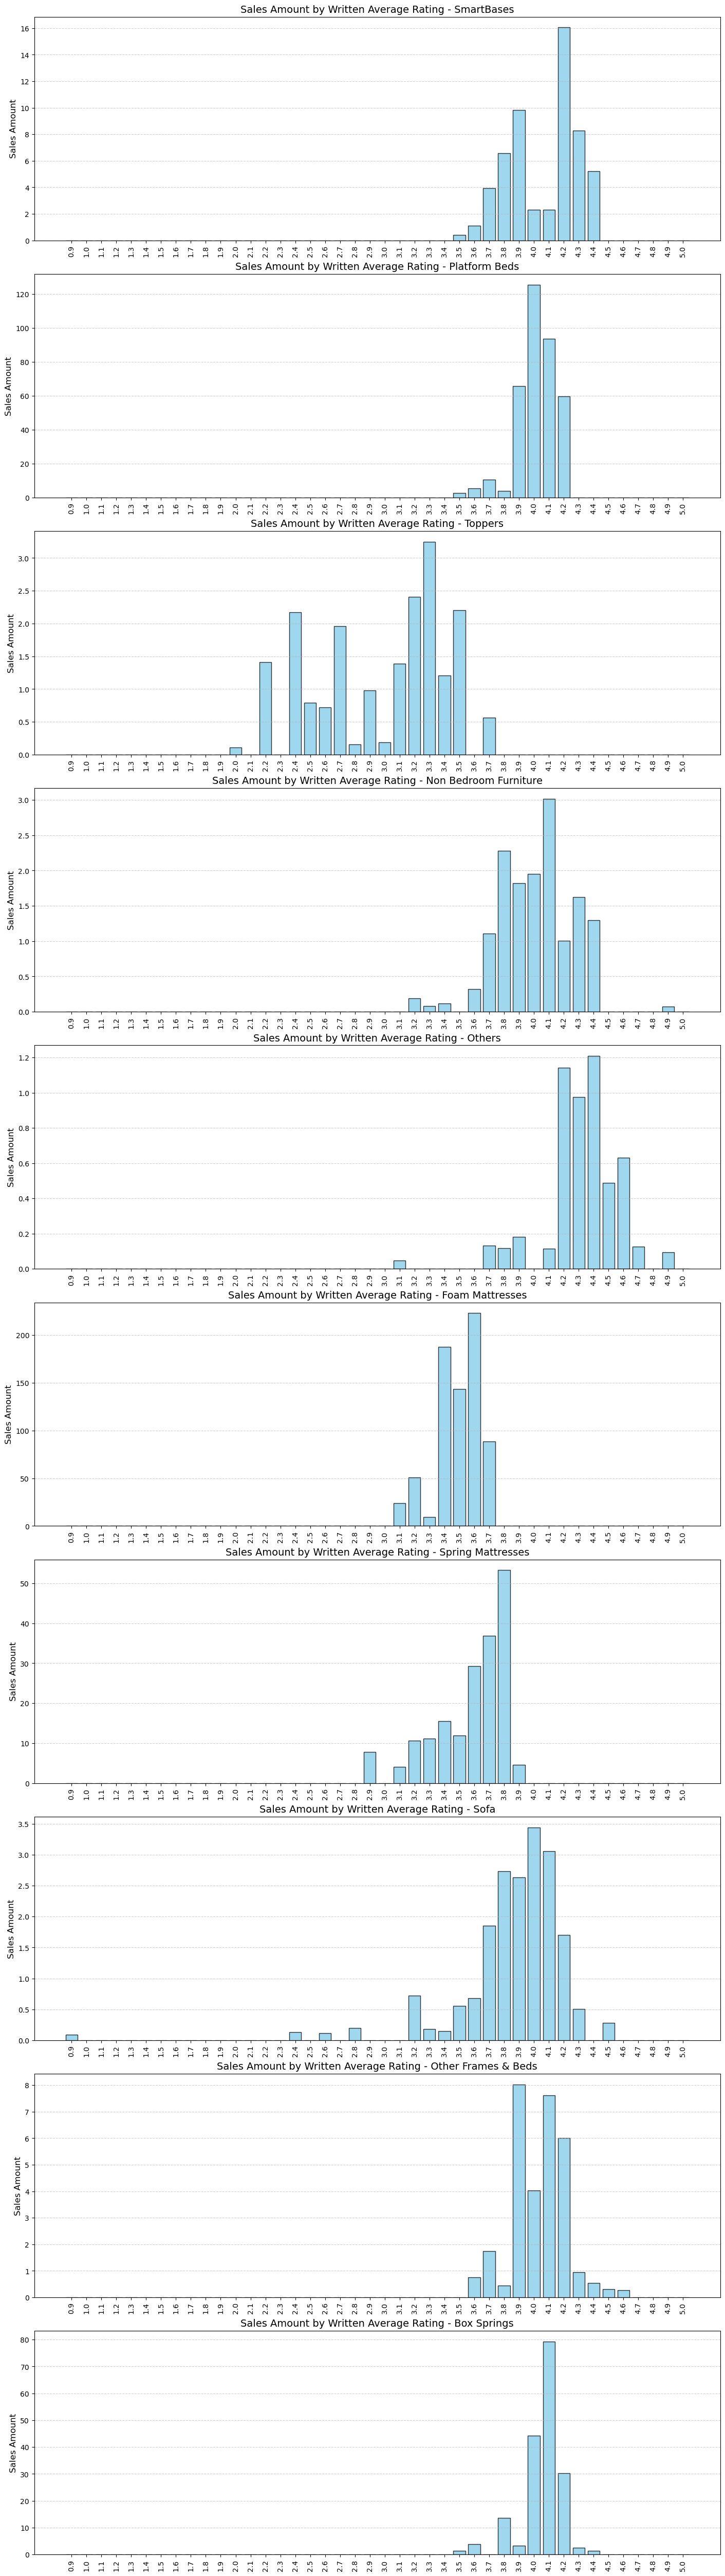

In [116]:
fig, axes = plt.subplots(num_categories, 1, figsize=(14,5*num_categories), constrained_layout=True)

for i, category in enumerate(categories):
    subset = data[data['financial_category']==category].copy()
    subset['rating_bin1'] = pd.cut(subset['written_avg_rating'], bins=bins1)
    rating_sales_sum = subset.groupby('rating_bin1')['sales_amount'].sum().fillna(0) / 1000000

    x_labels = [round(interval.left,1) for interval in rating_sales_sum.index]
    
    axes[i].bar(range(len(x_labels)), rating_sales_sum.values, color='skyblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Sales Amount by Written Average Rating - {category}', fontsize=14)
    #axes[i].set_xlabel('Written Average Rating (0.1 intervals)', fontsize=12)
    axes[i].set_ylabel('Sales Amount', fontsize=12)
    axes[i].set_xticks(range(len(x_labels)))
    axes[i].set_xticklabels(x_labels, rotation=90)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.show()